# Hamiltonian Chaos
We consider the standard (Chirikov) map
$$\begin{align}X_{n+1} &= X_n + Y_{n+1}\mod 2\pi\\Y_{n+1} &= Y_n + k\sin(X_n)\mod 2\pi.\end{align}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def chirikov_map(x, y, k=1.0):
    y_new = y + k*np.sin(x)
    x_new = x + y_new
    # wrap to [0, 2*pi)
    x_new = np.mod(x_new, 2*np.pi)
    y_new = np.mod(y_new, 2*np.pi)
    return x_new, y_new

def chirikov_series(x0, y0, n, k=1.0):
    xs = [x0]
    ys = [y0]
    for _ in range(n):
        x_new, y_new = chirikov_map(xs[-1], ys[-1], k=k)
        xs.append(x_new)
        ys.append(y_new)
    return xs, ys

def chirikov_map_iterations(x0, y0, n_total, n_skip, k=1.0):
    xs, ys = chirikov_series(x0, y0, n_total, k=k)
    return xs[n_skip:], ys[n_skip:]

### Visualizing dynamics
Below, we simulate the Chirikov map with $k=1$, and initial conditions along the diagonal $y_0 = x_0$.

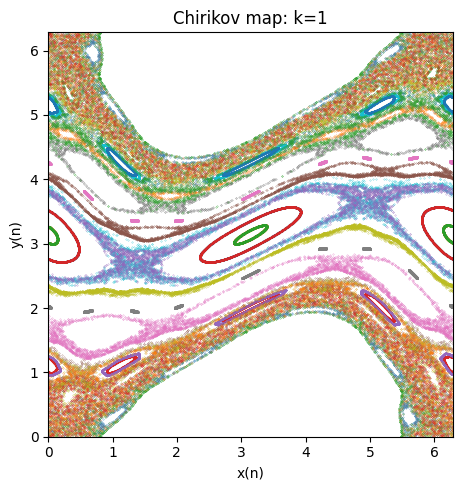

In [9]:
k = 1.0
ics = [2*np.pi*i/25 for i in range(1, 26)]
n_total = 5000
plt.figure(figsize=(5, 5))
for x0 in ics:
    xs, ys = chirikov_map_iterations(x0, x0, n_total, 0, k=k)
    xs = np.asarray(xs)
    ys = np.asarray(ys)
    plt.plot(xs, ys, '.', markersize=0.4)
plt.xlabel('x(n)')
plt.ylabel('y(n)')
plt.xlim(0, 2*np.pi)
plt.ylim(0, 2*np.pi)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Chirikov map: k=1')
plt.tight_layout()
plt.show()

The plot above clearly shows the chaotic sea and pockets (or islands) of periodic dynamics, which could also classify as quasiperiodic if we consider the Chirikov map as a Poincaré section of some higher dimensional system. We can see voids (or islands) not reached by the chosen initial conditions, guarding chaos from entering even though it might be contained inside, but that does not seem to be the case, as validated using various initial conditions offline.

Below, we repeat the map above with $k=0.5$ and $k=2$, which validates the notes.

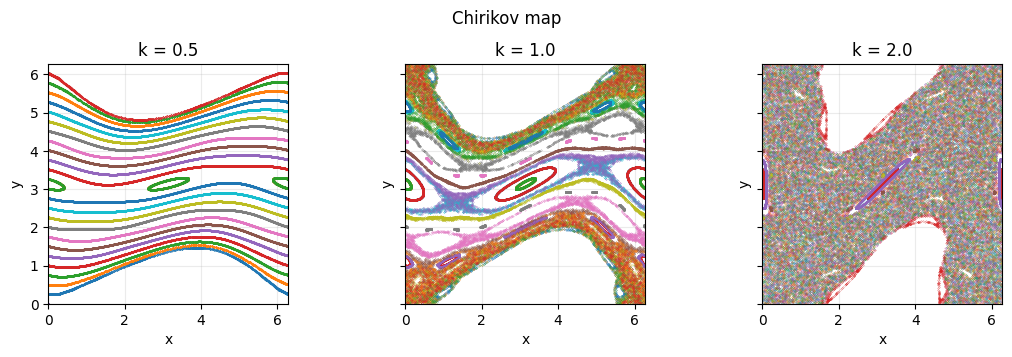

In [10]:
k_values = [0.5, 1.0, 2.0]
ics = [2*np.pi*i/25 for i in range(1, 26)]
n_total = 3000
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharex=True, sharey=True)
for ax, k in zip(axes, k_values):
    for x0 in ics:
        xs, ys = chirikov_map_iterations(x0, x0, n_total, 0, k=k)
        xs = np.asarray(xs)
        ys = np.asarray(ys)
        ax.plot(xs, ys, '.', markersize=0.4)
    ax.set_title(f'k = {k}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.xlim(0, 2*np.pi)
    plt.ylim(0, 2*np.pi)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.25)
fig.suptitle('Chirikov map')
plt.tight_layout()
plt.show()

For $k=0.5$, we can see islands of periodic and a sea of quasiperiodic dynamics in the $xy$ plane with no visibly prevalent chaos. This changes with $k=1$, as also seen above, with the chaotic sea becoming even stronger and engulfing most islands of periodic dynamics when $k=2$.

### Zooming in to see finer structure
We consider the Chirikov map with $k=1$ again, and zoom into the blue-green belt in the middle of the periodic belt of islands and the two voids at the top and bottom, which seems to have a similar structure as the full map over $[0, 2\pi)$ in both $x$ and $y$.

In [20]:
def chirikov_cloud(xvals, yvals, n_total, n_skip, k=1.0):
    xs_all = []
    ys_all = []
    for x0 in xvals:
        for y0 in yvals:
            xs, ys = chirikov_map_iterations(x0, y0, n_total, n_skip, k=k)
            xs_all.extend(xs)
            ys_all.extend(ys)
    return np.asarray(xs_all), np.asarray(ys_all)

xvals = np.linspace(4.75, 5.75, 50)
yvals = np.linspace(4.75, 5.75, 50)
xs, ys = chirikov_cloud(
    xvals, yvals,
    n_total=15000,
    n_skip=0,
    k=1.0
)

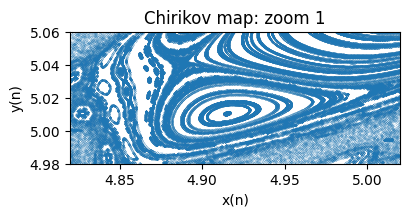

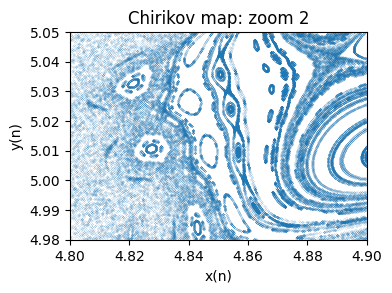

In [22]:
zoom_windows = [
    (4.82, 5.02, 4.98, 5.06),
    (4.8, 4.9, 4.98, 5.05),
]

for i, (xmin, xmax, ymin, ymax) in enumerate(zoom_windows, start=1):
    mask = (
        (xs >= xmin) & (xs <= xmax) &
        (ys >= ymin) & (ys <= ymax)
    )
    plt.figure(figsize=(4.2, 3.0))
    plt.plot(xs[mask], ys[mask], '.', markersize=0.2)
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel('x(n)')
    plt.ylabel('y(n)')
    plt.title(f'Chirikov map: zoom {i}')
    plt.tight_layout()
    plt.show()

The plots continue to show islands with rings and a chaotic sea around them, which is suggestive of a multiscale structure.

### Testing for Hamiltonian dynamics
By Liouville's theorem, Hamiltonian dynamics preserves the density of simultaneously evolved cluster of initial conditions. We will test this by measuring the area of a fixed number of points and seeing if it remains constant over repeated iterations of the Chirikov map.

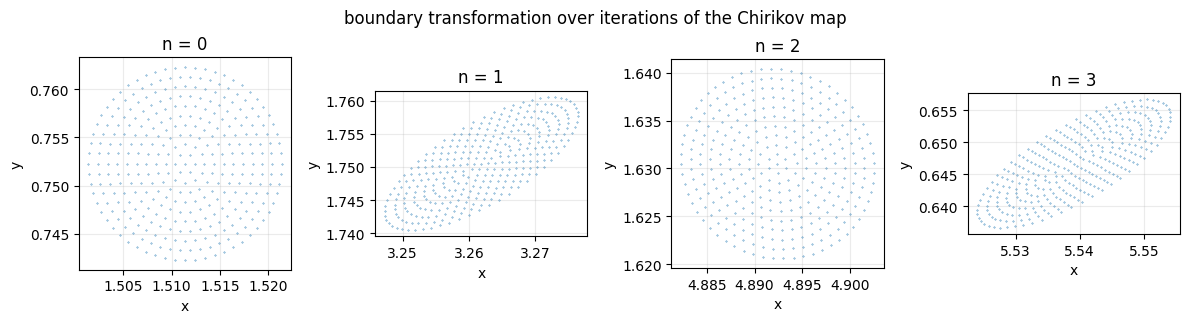

boundary-area estimates over the first 12 iterates:
n = 0: 0.00031416
n = 1: 0.00031416
n = 2: 0.00031416
n = 3: 0.00031416
n = 4: 0.00031416
n = 5: 0.00031416
n = 6: 0.00031416
n = 7: 0.00031416
n = 8: 0.00031416
n = 9: 0.00031416
n = 10: 0.00031416
n = 11: 0.00031416
n = 12: 0.00031416


In [ ]:
def unwrapped_chirikov_map(x, y, k=1.0):
    y_new = y + k*np.sin(x)
    x_new = x + y_new
    return x_new, y_new

def iterate_points(points, n_steps, k=1.0):
    pts = points.copy()
    for _ in range(n_steps):
        x_new, y_new = unwrapped_chirikov_map(pts[:, 0], pts[:, 1], k=k)
        pts = np.column_stack([x_new, y_new])
    return pts

def circle_cloud(xc, yc, r, n_rings=10):
    pts = [(xc, yc)]
    for j in range(1, n_rings + 1):
        rr = r * j / n_rings
        n_theta = 6 * j
        thetas = np.linspace(0, 2*np.pi, n_theta, endpoint=False)
        for theta in thetas:
            pts.append((xc + rr*np.cos(theta), yc + rr*np.sin(theta)))
    return np.asarray(pts)

def circle_boundary(xc, yc, r, n=1000):
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    x = xc + r*np.cos(theta)
    y = yc + r*np.sin(theta)
    return np.column_stack([x, y])

def polygon_area(xy):
    x = xy[:, 0]
    y = xy[:, 1]
    # shoelace formula: https://stackoverflow.com/questions/41077185/fastest-way-to-shoelace-formula
    return 0.5 * np.abs(np.sum(x*np.roll(y, -1) - y*np.roll(x, -1)))

# choose a center in the chaotic sea with k=1
xs_seed, ys_seed = chirikov_series(np.pi/25, np.pi/25, 1000, k=1.0)
xc = xs_seed[-1]
yc = ys_seed[-1]

# define initial circle of points
pts0 = circle_cloud(xc, yc, r=0.01, n_rings=10)
bdry0 = circle_boundary(xc, yc, r=0.01, n=1000)

# iterate and plot circle's evolution under the map
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    pts = iterate_points(pts0, i, k=1.0)
    ax.plot(pts[:, 0], pts[:, 1], '.', markersize=0.6)
    ax.set_title(f'n = {i}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.suptitle('boundary transformation over iterations of the Chirikov map', y=1.05)
plt.show()

# estimate area of the boundary's image under the map over iterations
print('boundary-area estimates over the first 12 iterates:')
for i in range(13):
    bdry = iterate_points(bdry0, i, k=1.0)
    print(f'n = {i}: {polygon_area(bdry):.8f}')